<a href="https://colab.research.google.com/github/python4recursion/bookcode/blob/main/Appendix-B/B_tail_recursion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Appendix B: tail_recursion.py

In [ ]:
def factorial1(n):
  if (n == 1):
    return 1
  return n * factorial1(n - 1)
def factorial2(n, acc = 1):
  if (n == 1):
    return acc
  return factorial2(n - 1, n * acc)
def factorial3(n):
  product = 1
  while (n > 0):
    product *= n;
    n -= 1
  return product

In [ ]:
def gcd1(a, b):
    if (b == 0):
        return a
    return gcd1(b, a % b)
def gcd2(a, b):
    while (b != 0):
        a, b = b, a % b
    return a

In [ ]:
def fib1(n):
    if (n <= 2):
        return 1
    return fib1(n - 1) + fib2(n-2)
def fib2(n, a = 1, b = 1):
    if (n <= 1):
        return a
    return fib2(n - 1, b, a + b)
def fib3(n):
    a, b = 1, 1
    for _ in range(1, n):
        a, b = b, a + b
    return a

In [ ]:
# test whether different implementations produce the same result
import random
# for n in range(20):
  # print(f'n = {n}, {fib1(n)}, {fib2(n)}, {fib3(n)}')
for _ in range(20):
  n = random.randint(10, 400)
  assert factorial1(n) == factorial2(n) == factorial3(n)
  # print(f'n = {n}, {fib1(n)}, {fib2(n)}, {fib3(n)}')
  assert fib1(n) == fib2(n) == fib3(n)
  m = random.randint(1, n)
  assert gcd1(n, m) == gcd2(n, m)
  # print(f'n={n}, m={m}, gcd1={gcd1(n, m)}, gcd2={gcd2(n, m)}')

In [ ]:
import time
def execution_time(func, r, repeat = 1):
  times = {}
  for n in r:
    start_time = time.time() # Record the start time
    for i in range(repeat):
      val = func(n)
    end_time = time.time() # Record the end time
    times[n] = (end_time - start_time) / repeat
  return times
r = range(11, 41)

In [ ]:
import time
def execution_time2(func, n, m, repeat = 1):
  times = {}
  for n in r:
    start_time = time.time() # Record the start time
    for i in range(repeat):
      val = func(n, m)
    end_time = time.time() # Record the end time
    times[n] = (end_time - start_time) / repeat
  return times

In [ ]:
r = range(10, 51)
repeat = 10000
timefib1 = execution_time(fib1, r, repeat)
timefib2 = execution_time(fib2, r, repeat)
timefib3 = execution_time(fib3, r, repeat)

In [ ]:
import matplotlib.pyplot as plt
def plot_execution_times(funcs, values, repeat = 10000):
  time = dict()
  for f in funcs:
    time[f.__name__] = execution_time(f, values, repeat)
  fig, ax = plt.subplots()
  for f in funcs:
    ax.plot(time[f.__name__].values(), label=f.__name__)
  ax.set_xlabel("n")
  ax.set_ylabel("Execution Time (s)")
  ax.set_yscale('log')
  ax.legend()
  plt.show()

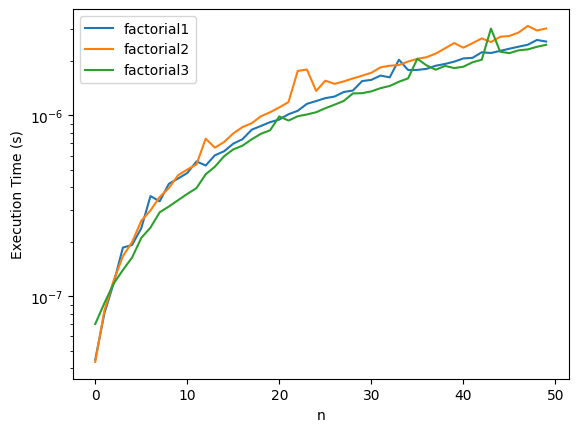

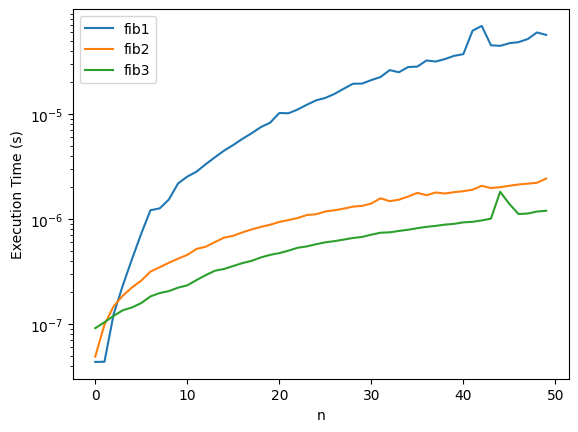

{1: 1.4274120330810547e-07, 2: 1.2249946594238282e-07, 3: 1.1987686157226563e-07, 4: 1.7745494842529296e-07, 5: 2.026081085205078e-07, 6: 1.1801719665527344e-07, 7: 1.220226287841797e-07, 8: 2.6535987854003906e-07, 9: 3.2346248626708985e-07, 10: 1.7223358154296876e-07, 11: 2.683401107788086e-07, 12: 1.5411376953125e-07, 13: 2.665519714355469e-07, 14: 1.1816024780273437e-07, 15: 1.9631385803222657e-07, 16: 2.658367156982422e-07, 17: 2.348184585571289e-07, 18: 2.005338668823242e-07, 19: 1.9567012786865234e-07, 20: 1.5594959259033203e-07, 21: 1.192331314086914e-07, 22: 2.3572444915771485e-07, 23: 2.3488998413085937e-07, 24: 1.9619464874267577e-07, 25: 1.959562301635742e-07, 26: 2.321004867553711e-07, 27: 2.0394325256347657e-07, 28: 1.6062259674072265e-07, 29: 1.5726089477539062e-07, 30: 1.9850730895996094e-07, 31: 2.3159980773925782e-07, 32: 2.3202896118164061e-07, 33: 2.0487308502197264e-07, 34: 2.6290416717529297e-07, 35: 1.578807830810547e-07, 36: 1.9733905792236328e-07, 37: 2.34031677

In [ ]:
r = range(1, 51)
repeat = 10000
plot_execution_times([factorial1, factorial2, factorial3], r, repeat)
plot_execution_times([fib1, fib2, fib3], r, repeat)
n = random.randint(10, 1000000)
m = random.randint(10, 1000000)
timegcd1 = execution_time2(gcd1, n, m, repeat)
timegcd2 = execution_time2(gcd2, n, m, repeat)
print (timegcd1)
print (timegcd2)

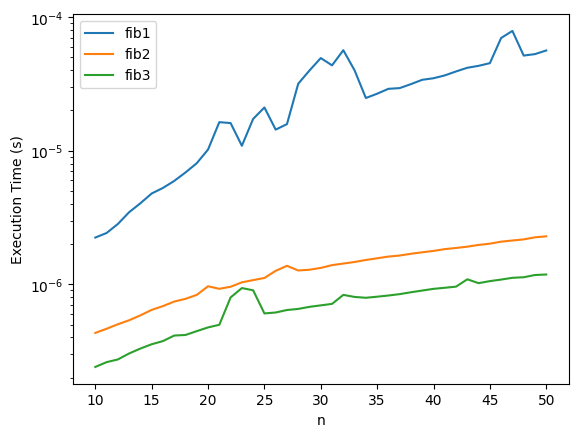

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(timefib1.keys(), timefib1.values(), label='fib1')
ax.plot(timefib2.keys(), timefib2.values(), label='fib2')
ax.plot(timefib3.keys(), timefib3.values(), label='fib3')
ax.set_xlabel("n")
ax.set_ylabel("Execution Time (s)")
ax.set_yscale('log')  # Set y-axis to logarithmic scale
ax.legend()
plt.show()